# Text & Statistic-Guided Multi-Modal Segmentation

In [ ]:

!pip install -q transformers>=4.40.0 timm einops peft
!pip install -q segmentation-models-pytorch
!pip install -q scipy scikit-image


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.3 MB/s eta 0:00:00


In [ ]:
import zipfile
import os
import pandas as pd
import numpy as np
import random, warnings
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torchvision import transforms
from scipy.ndimage import binary_dilation

from transformers import (
    SegformerForSemanticSegmentation,
    CLIPTokenizer,
    CLIPTextModel,
)
from peft import LoraConfig, get_peft_model, TaskType

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed()


In [ ]:
zip_path = '/content/Arşiv.zip'
extract_path = '/content/dataset'

os.makedirs(extract_path, exist_ok=True)

# extract Zip file
try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Extracted into {extract_path} file.")
except FileNotFoundError:
    print(f"{zip_path} couldn't find. ")

Extracted into /content/dataset file.


In [ ]:
IMG_DIR     = "/content/dataset/images"
MASK_DIR    = "/content/dataset/masks"
CAPTION_CSV = "/content/dataset/captions.csv"

OUTPUT_DIR  = '/content/outputs_stage2'

#Model Hyperparameters
NUM_CLASSES  = 7
IMG_SIZE     = 512
BATCH_SIZE   = 4
NUM_EPOCHS   = 10
LR           = 1e-5
LORA_LR      = 1e-4
WEIGHT_DECAY = 1e-4

#LoRA Configurations
LORA_RANK    = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05

#Focal Loss gamma
FOCAL_GAMMA  = 3.0

#Data columns
STAT_COLS   = ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']
CLASS_NAMES = ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']

#Color Map
COLOR_MAP = {
    (0,   100,  0): 0,   # Tree
    (255, 182,193): 1,   # Shrub
    (154, 205, 50): 2,   # Grass
    (255, 215,  0): 3,   # Crop
    (139,  69, 19): 4,   # Built-up
    (211, 211,211): 5,   # Barren
    (0,     0,255): 6,   # Water
}

import numpy as np
PALETTE = np.array([
    [  0, 100,  0],
    [255, 182,193],
    [154, 205, 50],
    [255, 215,  0],
    [139,  69, 19],
    [211, 211,211],
    [  0,   0,255],
], dtype=np.uint8)

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
if DEVICE == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device: cuda
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


In [ ]:
# Data Augmentation (CutMix)

def get_transforms(split='train'):
    if split == 'train':
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
            transforms.RandomGrayscale(p=0.05),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])

def cutmix_batch(images, masks, alpha=1.0):
    """CutMix: cutting and pasting small classes from another image to augment data."""
    B = images.size(0)
    lam = np.random.beta(alpha, alpha)
    rand_idx = torch.randperm(B)
    H, W = images.shape[2], images.shape[3]
    cut_rat = np.sqrt(1.0 - lam)
    cut_w = int(W * cut_rat); cut_h = int(H * cut_rat)
    cx = np.random.randint(W); cy = np.random.randint(H)
    x1 = max(cx - cut_w//2, 0); x2 = min(cx + cut_w//2, W)
    y1 = max(cy - cut_h//2, 0); y2 = min(cy + cut_h//2, H)
    images[:, :, y1:y2, x1:x2] = images[rand_idx, :, y1:y2, x1:x2]
    masks[:, y1:y2, x1:x2]     = masks[rand_idx, y1:y2, x1:x2]
    return images, masks

def rgb_mask_to_class(mask_rgb):
    h, w = mask_rgb.shape[:2]
    class_mask = np.zeros((h, w), dtype=np.int64)
    for rgb, cls_id in COLOR_MAP.items():
        match = np.all(mask_rgb == np.array(rgb, dtype=np.uint8), axis=-1)
        class_mask[match] = cls_id
    return class_mask

print('Augmentation.')


Augmentation.


In [ ]:

class RemoteSensingDataset(Dataset):
    def __init__(self, df, img_dir, mask_dir, split='train', max_captions=5):
        self.df           = df.reset_index(drop=True)
        self.img_dir      = img_dir
        self.mask_dir     = mask_dir
        self.transform    = get_transforms(split)
        self.caption_cols = [f'caption_{i}' for i in range(1, max_captions + 1)]
        for c in self.caption_cols:
            if c not in self.df.columns:
                self.df[c] = ''

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        fname = row['filename']
        img   = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
        img_t = self.transform(img)
        mask_rgb  = np.array(Image.open(os.path.join(self.mask_dir, fname)).convert('RGB'))
        class_map = rgb_mask_to_class(mask_rgb)
        mask_t    = torch.from_numpy(
            np.array(Image.fromarray(class_map.astype(np.uint8))
                     .resize((IMG_SIZE, IMG_SIZE), Image.NEAREST))
        ).long()
        stats    = row[STAT_COLS].values.astype(np.float32) / 100.0
        stats_t  = torch.tensor(stats)
        captions = [str(row[c]) for c in self.caption_cols]
        return img_t, mask_t, stats_t, captions, fname

print('Dataset is ready.')

Dataset is ready.


In [ ]:
# Automatic Class Weight Calculation
# It places greater emphasis on lower grades

def compute_class_weights(df, stat_cols, num_classes, device):
    """
    Calculates inverse-frequency weights from the percentage columns in the CSV file.
    If a class does not appear at all, the weight is 1.0.
    """
    freqs = df[stat_cols].mean().values.astype(np.float32) / 100.0
    freqs = np.clip(freqs, 1e-3, None)    # division by zero protection
    weights = 1.0 / freqs
    weights = weights / weights.sum() * num_classes   # normalize
    for name, w, f in zip(stat_cols, weights, freqs):
        print(f'  {name:<10}: freq={f*100:.1f}%  weight={w:.3f}')
    return torch.tensor(weights, dtype=torch.float32).to(device)

print('Ağırlık fonksiyonu tanımlandı.')

Ağırlık fonksiyonu tanımlandı.


In [ ]:
# LoRA-Enabled CLIP Text Encoder

class LoRACLIPTextEncoder(nn.Module):
    """
    LoRA adapters are added to the CLIP text encoder.
allows to fine-tune the encoder domain (satellite image text).    """
    def __init__(self, proj_dim=256, lora_rank=LORA_RANK,
                 lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT):
        super().__init__()
        self.tokenizer = CLIPTokenizer.from_pretrained('openai/clip-vit-base-patch32')
        base_clip      = CLIPTextModel.from_pretrained('openai/clip-vit-base-patch32')

        # LoRA configuration — added to the q and v attention matrices
        lora_cfg = LoraConfig(
            r              = lora_rank,
            lora_alpha     = lora_alpha,
            lora_dropout   = lora_dropout,
            target_modules = ['q_proj', 'v_proj'],  # CLIP attention layers
            bias           = 'none',
        )
        self.clip = get_peft_model(base_clip, lora_cfg)
        trainable, total = self.clip.get_nb_trainable_parameters()
        print(f'CLIP LoRA | Trainable: {trainable:,} / total: {total:,} '
              f'({100*trainable/total:.2f}%)')

        clip_dim = base_clip.config.hidden_size   # 512
        self.proj = nn.Sequential(
            nn.Linear(clip_dim, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.GELU(),
        )

    def forward(self, captions_batch):
        dev      = next(self.parameters()).device
        all_embs = []
        for caps in captions_batch:
            tokens = self.tokenizer(
                caps, padding=True, truncation=True,
                max_length=77, return_tensors='pt'
            ).to(dev)
            out = self.clip(**tokens).pooler_output   # (5, 512) — gradient
            all_embs.append(out.mean(dim=0, keepdim=True))
        return self.proj(torch.cat(all_embs, dim=0))

print('LoRA CLIP Encoder is ready.')

LoRA CLIP Encoder is ready.


In [ ]:
# Advanced Stat Encoder

class StatEncoder(nn.Module):
    """
    Difference from the baseline: dropout + a deeper MLP
    """
    def __init__(self, in_dim=7, proj_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.GELU(),
        )
    def forward(self, x):
        return self.net(x)

In [ ]:
#Multi-Scale Cross-Attention Fusion

class CrossAttentionFusion(nn.Module):
    """
    True cross-attention instead of the simple logit bias in Baseline:
    - The context vector (text+stat) is used as the query
    - Each pixel position serves as a key/value pair
    - Ensures that underrepresented classes focus on text-relevant regions
    """
    def __init__(self, img_channels, cond_dim, num_heads=8):
        super().__init__()
        # Align cond_dim to img_channels

        self.cond_proj = nn.Linear(cond_dim, img_channels)
        self.attn      = nn.MultiheadAttention(
            embed_dim=img_channels, num_heads=num_heads,
            batch_first=True, dropout=0.1
        )
        self.norm      = nn.LayerNorm(img_channels)
        self.gate      = nn.Sequential(
            nn.Linear(img_channels, img_channels),
            nn.Sigmoid()
        )

    def forward(self, feat_map, cond_vec):
        """
        feat_map : (B, C, H, W)
        cond_vec : (B, cond_dim)
        """
        B, C, H, W = feat_map.shape
        # Convert to a pixel array: (B, H*W, C)
        feat_flat  = feat_map.flatten(2).transpose(1, 2)
        # Condition → query: (B, 1, C)
        query      = self.cond_proj(cond_vec).unsqueeze(1)
        # Cross-attention: query cond, key/value feature map
        attn_out, _ = self.attn(query, feat_flat, feat_flat)
        # Gate: Which channels should be activated and to what extent
        gate        = self.gate(attn_out.squeeze(1))  # (B, C)
        gate        = gate.unsqueeze(-1).unsqueeze(-1) # (B, C, 1, 1)
        fused       = feat_map * gate
        return self.norm(fused.flatten(2).transpose(1,2)).transpose(1,2).view(B, C, H, W)


class MultiScaleFusion(nn.Module):
    """
    It applies and combines cross-attention at three different resolutions.
    Small objects often get lost at low scales (high resolution);
    this module conditions each scale separately.
    """
    def __init__(self, img_channels=256, cond_dim=320):
        super().__init__()
        self.ca_full    = CrossAttentionFusion(img_channels, cond_dim, num_heads=8)
        self.ca_half    = CrossAttentionFusion(img_channels, cond_dim, num_heads=8)
        self.ca_quarter = CrossAttentionFusion(img_channels, cond_dim, num_heads=8)
        self.merge      = nn.Conv2d(img_channels * 3, img_channels, 1)

    def forward(self, feat_map, cond_vec):
        B, C, H, W = feat_map.shape
        # Full scale
        out_full    = self.ca_full(feat_map, cond_vec)
        # Half Scale
        feat_half   = F.avg_pool2d(feat_map, 2)
        out_half    = self.ca_half(feat_half, cond_vec)
        out_half    = F.interpolate(out_half, size=(H, W), mode='bilinear', align_corners=False)
        # Quarter scale
        feat_qrt    = F.avg_pool2d(feat_map, 4)
        out_qrt     = self.ca_quarter(feat_qrt, cond_vec)
        out_qrt     = F.interpolate(out_qrt, size=(H, W), mode='bilinear', align_corners=False)
        # concanate
        merged = torch.cat([out_full, out_half, out_qrt], dim=1)
        return self.merge(merged)

In [ ]:
#

class Stage2MultiModalSegformer(nn.Module):
    """
    Enhancements added to the baseline:
    1. LoRA-fine-tuned CLIP
    2. Deep Stat MLP
    3. Multi-Scale Cross-Attention Fusion
    4. Auxiliary head (additional supervision for minor classes)
    """
    def __init__(self, num_classes=NUM_CLASSES, text_proj=256, stat_proj=64):
        super().__init__()
        id2label = {i: n for i, n in enumerate(CLASS_NAMES)}
        label2id = {n: i for i, n in enumerate(CLASS_NAMES)}

        # SegFormer-B2 (backbone)
        self.segformer = SegformerForSemanticSegmentation.from_pretrained(
            'nvidia/mit-b2',
            num_labels=num_classes,
            id2label=id2label,
            label2id=label2id,
            ignore_mismatched_sizes=True,
        )

        # Encoders
        self.text_enc = LoRACLIPTextEncoder(proj_dim=text_proj)
        self.stat_enc = StatEncoder(proj_dim=stat_proj)

        cond_dim = text_proj + stat_proj   # 320

        # SegFormer decode head output channel (pre-logit, consisting of 256 units for B2)
        # However, instead of using a forward hook, I apply parallel fusion to the logits
        # Logit-space multi-scale fusion (simple and robust)
        decode_channels = num_classes
        self.ms_cond_proj = nn.Sequential(
            nn.Linear(cond_dim, 128), nn.ReLU(),
            nn.Linear(128, num_classes * 3)  # Separate bias for 3 scales
        )

        # Auxiliary head: How well does statistical information predict outcomes on its own?
        self.aux_head = nn.Sequential(
            nn.Linear(cond_dim, 128), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, images, stats, captions, return_aux=True):
        # 1. SegFormer logits
        logits = self.segformer(pixel_values=images).logits  # (B, C, H/4, W/4)
        H0, W0 = images.shape[2], images.shape[3]
        H4, W4 = logits.shape[2], logits.shape[3]

        # 2. Condition vector
        text_emb = self.text_enc(captions)                    # (B, 256)
        stat_emb = self.stat_enc(stats)                       # (B, 64)
        cond     = torch.cat([text_emb, stat_emb], dim=-1)   # (B, 320)

        # 3. Multi-scale logit conditioning
        ms_bias = self.ms_cond_proj(cond)                     # (B, C*3)
        B, C3   = ms_bias.shape
        C       = C3 // 3
        bias_full = ms_bias[:, :C].unsqueeze(-1).unsqueeze(-1)
        bias_half = ms_bias[:, C:2*C].unsqueeze(-1).unsqueeze(-1)
        bias_qrt  = ms_bias[:, 2*C:].unsqueeze(-1).unsqueeze(-1)

        # Full-scale logit
        logits_full = logits + bias_full

        logits_half = F.interpolate(logits, size=(H4*2, W4*2), mode='bilinear', align_corners=False)
        logits_half = logits_half + bias_half
        logits_half = F.interpolate(logits_half, size=(H4, W4), mode='bilinear', align_corners=False)
        # 1/4 scale
        logits_qrt  = F.avg_pool2d(logits, 2) + bias_qrt
        logits_qrt  = F.interpolate(logits_qrt, size=(H4, W4), mode='bilinear', align_corners=False)

        # Scale average
        logits_fused = (logits_full + logits_half + logits_qrt) / 3.0

        #4. Upsample to original size
        output = F.interpolate(logits_fused, size=(H0, W0), mode='bilinear', align_corners=False)

        if return_aux:
            aux_logits = self.aux_head(cond)   # (B, C) — global statistic prediction
            return output, aux_logits
        return output

In [ ]:
# Advance Loss Functions

class FocalLoss(nn.Module):
    """
    Focal Loss: Less emphasis on easy examples, more emphasis on difficult (small/rare) classes.
    As gamma increases, small classes are learned more effectively.
    """
    def __init__(self, gamma=FOCAL_GAMMA, weight=None, ignore_index=255):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight
        self.ignore = ignore_index

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits, targets,
            weight=self.weight,
            ignore_index=self.ignore,
            reduction='none'
        )
        p_t     = torch.exp(-ce_loss)
        focal   = ((1 - p_t) ** self.gamma) * ce_loss
        mask    = targets != self.ignore
        return focal[mask].mean()


class BoundaryLoss(nn.Module):
    """
    Boundary-Aware Loss: It applies an extra penalty to pixels at class boundaries.
    It helps the model better learn the edges of small objects.
    """
    def __init__(self, num_classes=NUM_CLASSES, dilation=3):
        super().__init__()
        self.num_classes = num_classes
        self.dilation    = dilation

    def get_boundary_mask(self, mask_np):
        """Remove boundary pixels from the NumPy mask."""
        boundary = np.zeros_like(mask_np, dtype=bool)
        for cls in range(self.num_classes):
            cls_mask  = (mask_np == cls)
            dilated   = binary_dilation(cls_mask, iterations=self.dilation)
            boundary |= (dilated & ~cls_mask)
        return boundary

    def forward(self, logits, targets):
        """
        Applies CE loss to boundary pixels.
        """
        targets_np = targets.detach().cpu().numpy()
        boundary_weights = torch.ones_like(targets, dtype=torch.float32)
        for b in range(targets_np.shape[0]):
            bnd = self.get_boundary_mask(targets_np[b])
            boundary_weights[b][bnd] = 3.0   # 3x the weight of the bounds
        boundary_weights = boundary_weights.to(logits.device)
        ce = F.cross_entropy(logits, targets, ignore_index=255, reduction='none')
        return (ce * boundary_weights).mean()


class DiceLoss(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.num_classes = num_classes

    def forward(self, logits, targets, eps=1e-6):
        probs   = F.softmax(logits, dim=1)
        B, C, H, W = probs.shape
        one_hot = F.one_hot(targets.clamp(0, C-1), C).permute(0,3,1,2).float()
        inter   = (probs * one_hot).sum(dim=(2,3))
        union   = probs.sum(dim=(2,3)) + one_hot.sum(dim=(2,3))
        return 1 - ((2*inter + eps) / (union + eps)).mean()


class AuxStatLoss(nn.Module):
    """
    Auxiliary loss: the class probabilities predicted by aux_head
    are compared to the actual statistics using MSE.
    """
    def forward(self, aux_logits, stats):
        pred_dist = F.softmax(aux_logits, dim=-1)   # (B, C)
        return F.mse_loss(pred_dist, stats)


class Stage2CombinedLoss(nn.Module):
    def __init__(self, class_weights, num_classes=NUM_CLASSES):
        super().__init__()
        self.focal    = FocalLoss(gamma=FOCAL_GAMMA, weight=class_weights)
        self.dice     = DiceLoss(num_classes)
        self.boundary = BoundaryLoss(num_classes)
        self.aux_stat = AuxStatLoss()
        # Loss weights
        self.w_focal    = 0.40
        self.w_dice     = 0.35
        self.w_boundary = 0.15
        self.w_aux      = 0.10

    def forward(self, logits, targets, aux_logits, stats):
        focal    = self.focal(logits, targets)
        dice     = self.dice(logits, targets)
        boundary = self.boundary(logits, targets)
        aux      = self.aux_stat(aux_logits, stats)
        total    = (self.w_focal * focal + self.w_dice * dice +
                    self.w_boundary * boundary + self.w_aux * aux)
        return total, {
            'focal'   : focal.item(),
            'dice'    : dice.item(),
            'boundary': boundary.item(),
            'aux_stat': aux.item(),
        }

In [ ]:


def compute_metrics(preds_np, labels_np, num_classes=NUM_CLASSES):
    valid = labels_np != 255
    p, l  = preds_np[valid], labels_np[valid]
    pixel_acc = (p == l).mean()
    per_iou, per_dice = {}, {}
    for cls in range(num_classes):
        tp = ((p==cls)&(l==cls)).sum()
        fp = ((p==cls)&(l!=cls)).sum()
        fn = ((p!=cls)&(l==cls)).sum()
        if tp+fp+fn == 0:
            per_iou[CLASS_NAMES[cls]]  = float('nan')
            per_dice[CLASS_NAMES[cls]] = float('nan')
        else:
            per_iou[CLASS_NAMES[cls]]  = tp/(tp+fp+fn+1e-8)
            per_dice[CLASS_NAMES[cls]] = (2*tp)/(2*tp+fp+fn+1e-8)
    return {
        'pixel_acc': float(pixel_acc),
        'mean_iou' : float(np.nanmean(list(per_iou.values()))),
        'mean_dice': float(np.nanmean(list(per_dice.values()))),
        'per_class_iou' : per_iou,
        'per_class_dice': per_dice,
    }

In [ ]:
#Training & Validation Functions

class MetricLogger:
    def __init__(self): self.history = defaultdict(list)
    def save(self, path):
        pd.DataFrame(self.history).to_csv(path, index=False)
        print(f'Saved → {path}')

def train_one_epoch(model, loader, optimizer, criterion, device,
                    use_cutmix=True, cutmix_prob=0.3):
    model.train()
    total = defaultdict(float)
    all_preds, all_labels = [], []

    for imgs, masks, stats, captions, _ in tqdm(loader, desc='Train', leave=False):
        imgs, masks, stats = imgs.to(device), masks.to(device), stats.to(device)

        # CutMix augmentation (where small classes are sampled from other images)
        if use_cutmix and random.random() < cutmix_prob:
            imgs, masks = cutmix_batch(imgs, masks)

        optimizer.zero_grad()
        logits, aux_logits = model(imgs, stats, captions, return_aux=True)
        loss, loss_dict    = criterion(logits, masks, aux_logits, stats)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total['loss'] += loss.item()
        for k, v in loss_dict.items():
            total[k] += v
        all_preds.append(logits.argmax(1).detach().cpu().numpy().ravel())
        all_labels.append(masks.cpu().numpy().ravel())

    m = compute_metrics(np.concatenate(all_preds), np.concatenate(all_labels))
    n = len(loader)
    return {k: v/n for k, v in total.items()} | m

@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total = defaultdict(float)
    all_preds, all_labels = [], []

    for imgs, masks, stats, captions, _ in tqdm(loader, desc='Val  ', leave=False):
        imgs, masks, stats = imgs.to(device), masks.to(device), stats.to(device)
        logits, aux_logits = model(imgs, stats, captions, return_aux=True)
        loss, loss_dict    = criterion(logits, masks, aux_logits, stats)
        total['loss'] += loss.item()
        for k, v in loss_dict.items():
            total[k] += v
        all_preds.append(logits.argmax(1).cpu().numpy().ravel())
        all_labels.append(masks.cpu().numpy().ravel())

    m = compute_metrics(np.concatenate(all_preds), np.concatenate(all_labels))
    n = len(loader)
    return {k: v/n for k, v in total.items()} | m


In [ ]:
# Visualization Function

def plot_training_curves(logger, save_dir):
    h = logger.history
    fig, axes = plt.subplots(3, 3, figsize=(20, 15))
    fig.suptitle('Stage 2 — Training metrics', fontsize=15, fontweight='bold')

    configs = [
        ('loss',       'Toplam Loss',         'Loss',    'tab:red'),
        ('focal',      'Focal Loss',          'Loss',    'tab:orange'),
        ('dice',       'Dice Loss',           'Loss',    'tab:purple'),
        ('boundary',   'Boundary Loss',       'Loss',    'tab:brown'),
        ('aux_stat',   'Aux Stat Loss',       'Loss',    'tab:pink'),
        ('pixel_acc',  'Pixel Accuracy',      'Acc',     'tab:blue'),
        ('mean_iou',   'Mean IoU',            'mIoU',    'tab:green'),
        ('mean_dice',  'Mean Dice (F1)',      'Dice',    'tab:cyan'),
    ]
    epochs = range(1, len(h.get('train_loss', [1]))+1)

    for ax, (key, title, ylabel, color) in zip(axes.ravel(), configs):
        tk = f'train_{key}'; vk = f'val_{key}'
        if tk in h:
            ax.plot(epochs, h[tk], label='Train', color=color, linewidth=2)
        if vk in h:
            ax.plot(epochs, h[vk], label='Val',   color=color,
                    linestyle='--', linewidth=2)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(); ax.grid(alpha=0.3)

    # Per class
    ax = axes.ravel()[-1]
    if 'val_mean_iou' in h and len(h['val_mean_iou']) > 0:
        best_ep = int(np.argmax(h['val_mean_iou']))
        ax.set_title(f'Best Epoch: {best_ep+1}\nmIoU={h["val_mean_iou"][best_ep]:.4f}',
                     fontsize=11, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    out = os.path.join(save_dir, 'stage2_training_curves.png')
    plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
    print(f'Saved → {out}')




def visualize_predictions(model, dataset, device, save_dir, n=4, epoch=0):
    model.eval()
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    fig, axes = plt.subplots(n, 3, figsize=(14, 4*n))
    if n == 1: axes = axes[np.newaxis, :]
    with torch.no_grad():
        for ri, idx in enumerate(indices):
            img_t, mask_t, stats_t, captions, fname = dataset[idx]
            logit, _ = model(img_t.unsqueeze(0).to(device),
                             stats_t.unsqueeze(0).to(device), [captions])
            pred    = logit.argmax(1).squeeze().cpu().numpy()
            img_np  = img_t.permute(1,2,0).numpy()
            img_np  = (img_np*np.array([0.229,0.224,0.225])+np.array([0.485,0.456,0.406])).clip(0,1)
            gt_np   = mask_t.numpy()
            # IoU calculation
            valid   = gt_np.ravel() != 255
            sample_iou = compute_metrics(pred.ravel()[valid], gt_np.ravel()[valid])['mean_iou']
            axes[ri,0].imshow(img_np)
            axes[ri,0].set_title(f'{fname}', fontsize=9); axes[ri,0].axis('off')
            axes[ri,1].imshow(PALETTE[gt_np])
            axes[ri,1].set_title('Ground Truth'); axes[ri,1].axis('off')
            axes[ri,2].imshow(PALETTE[pred])
            axes[ri,2].set_title(f'Tahmin  mIoU={sample_iou:.3f}'); axes[ri,2].axis('off')
    patches = [mpatches.Patch(color=PALETTE[i]/255, label=CLASS_NAMES[i]) for i in range(NUM_CLASSES)]
    fig.legend(handles=patches, loc='lower center', ncol=NUM_CLASSES, fontsize=9)
    plt.suptitle(f'Prediction— Epoch {epoch}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    out = os.path.join(save_dir, f'predictions_ep{epoch:03d}.png')
    plt.savefig(out, dpi=120, bbox_inches='tight'); plt.show()


def plot_loss_breakdown(logger, save_dir):
    """The change in each loss component over the course of training."""
    h      = logger.history
    epochs = range(1, len(h.get('train_loss', []))+1)
    loss_keys = ['focal', 'dice', 'boundary', 'aux_stat']
    colors    = ['tab:orange', 'tab:purple', 'tab:brown', 'tab:pink']
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for key, color in zip(loss_keys, colors):
        if f'train_{key}' in h:
            axes[0].plot(epochs, h[f'train_{key}'], label=key, color=color, linewidth=2)
        if f'val_{key}' in h:
            axes[1].plot(epochs, h[f'val_{key}'],   label=key, color=color, linewidth=2)
    for ax, title in zip(axes, ['Train Loss ', 'Val Loss ']):
        ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    out = os.path.join(save_dir, 'loss_breakdown.png')
    plt.savefig(out, dpi=130, bbox_inches='tight'); plt.show()
    print(f'Saved → {out}')


In [ ]:
# Data loading

df = pd.read_csv(CAPTION_CSV)
print(f'Total: {len(df)} | Split :')
print(df['split'].value_counts())

train_df = df[df['split']=='train'].reset_index(drop=True)
val_df   = df[df['split']=='val'].reset_index(drop=True)

if len(val_df) == 0:
    all_df   = df.reset_index(drop=True)
    n        = int(len(all_df)*0.8)
    train_df = all_df.iloc[:n].reset_index(drop=True)
    val_df   = all_df.iloc[n:].reset_index(drop=True)
    print(f'Automatic 80/20 split: Train={len(train_df)} Val={len(val_df)}')

# Calculate class weights
class_weights = compute_class_weights(train_df, STAT_COLS, NUM_CLASSES, DEVICE)

train_ds     = RemoteSensingDataset(train_df, IMG_DIR, MASK_DIR, split='train')
val_ds       = RemoteSensingDataset(val_df,   IMG_DIR, MASK_DIR, split='val')
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'\nTrain: {len(train_ds)} | Val: {len(val_ds)}')

Total: 10000 | Split :
split
synth    10000
Name: count, dtype: int64
Automatic 80/20 split: Train=8000 Val=2000
Sınıf ağırlıkları:
  Tree      : freq=29.1%  weight=0.078
  Shrub     : freq=0.8%  weight=2.803
  Grass     : freq=45.4%  weight=0.050
  Crop      : freq=17.8%  weight=0.128
  Built-up  : freq=1.1%  weight=2.051
  Barren    : freq=4.2%  weight=0.541
  Water     : freq=1.7%  weight=1.350

Train: 8000 | Val: 2000


In [ ]:
# Model training and optimization
!pip install -q -U torchao

model     = Stage2MultiModalSegformer(num_classes=NUM_CLASSES).to(DEVICE)
criterion = Stage2CombinedLoss(class_weights=class_weights)

# Parameter groups: LoRA and new layers achieve higher learning rates
lora_params    = [p for n,p in model.named_parameters() if 'lora_' in n and p.requires_grad]
new_params     = [p for n,p in model.named_parameters()
                  if 'lora_' not in n and 'segformer' not in n and p.requires_grad]
base_params    = [p for n,p in model.named_parameters()
                  if 'segformer' in n and 'lora_' not in n and p.requires_grad]

optimizer = AdamW([
    {'params': base_params, 'lr': LR,      'name': 'segformer_base'},
    {'params': lora_params, 'lr': LORA_LR, 'name': 'lora_adapters'},
    {'params': new_params,  'lr': LR * 5,  'name': 'new_modules'},
], weight_decay=WEIGHT_DECAY)

scheduler = OneCycleLR(
    optimizer, max_lr=[LR, LORA_LR, LR*5],
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS, pct_start=0.1,
)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal parameter   : {total_p:,}')
print(f'Trainable param.: {trainable_p:,} ({100*trainable_p/total_p:.1f}%)')
print(f'  LoRA  : {sum(p.numel() for p in lora_params):,}')
print(f'  new modules    : {sum(p.numel() for p in new_params):,}')
print(f'  SegFormer base   : {sum(p.numel() for p in base_params):,}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 70.5 MB/s eta 0:00:00


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/99.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP LoRA | Trainable: 393,216 / total: 63,559,168 (0.62%)

Total parameter   : 91,154,723
Trainable param.: 27,988,771 (30.7%)
  LoRA  : 393,216
  new modules    : 243,548
  SegFormer base   : 27,352,007


In [ ]:


if 'model' not in locals() and 'model' not in globals():
    raise NameError("Error: The ‘model’ variable was not found. ")

# updating the forward function to correct the text size from DataLoader
def new_text_enc_forward(self, captions_batch):
    dev = next(self.parameters()).device
    # captions_batch consists of 5 tuples, each of length BATCH_SIZE (4).
    # convert this into BATCH_SIZE tuples, each of length 5.
    transposed = list(zip(*captions_batch))
    all_embs = []
    for caps in transposed:
        tokens = self.tokenizer(
            list(caps), padding=True, truncation=True,
            max_length=77, return_tensors='pt'
        ).to(dev)
        out = self.clip(**tokens).pooler_output
        all_embs.append(out.mean(dim=0, keepdim=True))
    return self.proj(torch.cat(all_embs, dim=0))

import types
model.text_enc.forward = types.MethodType(new_text_enc_forward, model.text_enc)

logger    = MetricLogger()
best_miou = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    train_m = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE,
        use_cutmix=True, cutmix_prob=0.3
    )
    val_m   = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    for k, v in train_m.items():
        if isinstance(v, float): logger.history[f'train_{k}'].append(v)
    for k, v in val_m.items():
        if isinstance(v, float): logger.history[f'val_{k}'].append(v)

    # ── Epoch raporu
    print(f'\n{'='*70}')
    print(f'[Epoch {epoch:03d}/{NUM_EPOCHS}]')
    print(f'  TRAIN  Total:{train_m["loss"]:.4f}  Focal:{train_m["focal"]:.4f}  '
          f'Dice:{train_m["dice"]:.4f}  Bnd:{train_m["boundary"]:.4f}  Aux:{train_m["aux_stat"]:.4f}')
    print(f'  VAL    Total:{val_m["loss"]:.4f}  Focal:{val_m["focal"]:.4f}  '
          f'Dice:{val_m["dice"]:.4f}  Bnd:{val_m["boundary"]:.4f}  Aux:{val_m["aux_stat"]:.4f}')
    print(f'  Train  PixAcc:{train_m["pixel_acc"]:.4f}  mIoU:{train_m["mean_iou"]:.4f}  mDice:{train_m["mean_dice"]:.4f}')
    print(f'  Val    PixAcc:{val_m["pixel_acc"]:.4f}    mIoU:{val_m["mean_iou"]:.4f}    mDice:{val_m["mean_dice"]:.4f}')

    per = ' | '.join(f'{c}:{v:.3f}' for c,v in val_m['per_class_iou'].items())
    print(f'  Per-Class IoU: {per}')

    # ── En iyi model
    if val_m['mean_iou'] > best_miou:
        best_miou = val_m['mean_iou']
        ckpt = os.path.join(OUTPUT_DIR, 'best_stage2_model.pth')
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'best_miou': best_miou,
            'val_metrics': val_m,
        }, ckpt)
        print(f'  Best model saved (mIoU={best_miou:.4f}) → {ckpt}')

print('\nCompleted!')


[Epoch 001/10]
  TRAIN  Total:0.6111  Focal:0.2290  Dice:0.8811  Bnd:1.3786  Aux:0.0431
  VAL    Total:0.5226  Focal:0.1733  Dice:0.8605  Bnd:0.9906  Aux:0.0355
  Train  PixAcc:0.6404  mIoU:0.2041  mDice:0.2765
  Val    PixAcc:0.7581    mIoU:0.3391    mDice:0.4422
  Per-Class IoU: Tree:0.676 | Shrub:0.000 | Grass:0.646 | Crop:0.609 | Built-up:0.092 | Barren:0.088 | Water:0.263
  Best model saved (mIoU=0.3391) → /content/outputs_stage2/best_stage2_model.pth



[Epoch 002/10]
  TRAIN  Total:0.5881  Focal:0.2258  Dice:0.8744  Bnd:1.2590  Aux:0.0291
  VAL    Total:0.5011  Focal:0.1463  Dice:0.8552  Bnd:0.9405  Aux:0.0218
  Train  PixAcc:0.6845  mIoU:0.2349  mDice:0.3076
  Val    PixAcc:0.7727    mIoU:0.4308    mDice:0.5500
  Per-Class IoU: Tree:0.685 | Shrub:0.000 | Grass:0.653 | Crop:0.634 | Built-up:0.304 | Barren:0.152 | Water:0.588
  Best model saved (mIoU=0.4308) → /content/outputs_stage2/best_stage2_model.pth



[Epoch 003/10]
  TRAIN  Total:0.5722  Focal:0.2162  Dice:0.8701  Bnd:1.1955  Aux:0.0187
  VAL    Total:0.4878  Focal:0.1272  Dice:0.8524  Bnd:0.9151  Aux:0.0133
  Train  PixAcc:0.7037  mIoU:0.2564  mDice:0.3363
  Val    PixAcc:0.7788    mIoU:0.4625    mDice:0.5826
  Per-Class IoU: Tree:0.687 | Shrub:0.000 | Grass:0.657 | Crop:0.651 | Built-up:0.379 | Barren:0.202 | Water:0.662
  Best model saved (mIoU=0.4625) → /content/outputs_stage2/best_stage2_model.pth



[Epoch 004/10]
  TRAIN  Total:0.5583  Focal:0.2048  Dice:0.8672  Bnd:1.1439  Aux:0.0124
  VAL    Total:0.4745  Focal:0.1023  Dice:0.8517  Bnd:0.8966  Aux:0.0097
  Train  PixAcc:0.7189  mIoU:0.2866  mDice:0.3816
  Val    PixAcc:0.7820    mIoU:0.4729    mDice:0.5960
  Per-Class IoU: Tree:0.687 | Shrub:0.008 | Grass:0.656 | Crop:0.670 | Built-up:0.415 | Barren:0.235 | Water:0.639
  Best model saved (mIoU=0.4729) → /content/outputs_stage2/best_stage2_model.pth



[Epoch 005/10]
  TRAIN  Total:0.5486  Focal:0.1968  Dice:0.8646  Bnd:1.1085  Aux:0.0098
  VAL    Total:0.4750  Focal:0.0953  Dice:0.8514  Bnd:0.9199  Aux:0.0085
  Train  PixAcc:0.7285  mIoU:0.3151  mDice:0.4231
  Val    PixAcc:0.7776    mIoU:0.4605    mDice:0.5923
  Per-Class IoU: Tree:0.686 | Shrub:0.048 | Grass:0.652 | Crop:0.676 | Built-up:0.384 | Barren:0.249 | Water:0.530



[Epoch 006/10]
  TRAIN  Total:0.5380  Focal:0.1833  Dice:0.8627  Bnd:1.0790  Aux:0.0087
  VAL    Total:0.4811  Focal:0.0874  Dice:0.8543  Bnd:0.9756  Aux:0.0082
  Train  PixAcc:0.7379  mIoU:0.3458  mDice:0.4626
  Val    PixAcc:0.7679    mIoU:0.4489    mDice:0.5857
  Per-Class IoU: Tree:0.673 | Shrub:0.089 | Grass:0.653 | Crop:0.678 | Built-up:0.288 | Barren:0.278 | Water:0.484



[Epoch 007/10]
  TRAIN  Total:0.5301  Focal:0.1732  Dice:0.8618  Bnd:1.0556  Aux:0.0084
  VAL    Total:0.4854  Focal:0.1007  Dice:0.8545  Bnd:0.9687  Aux:0.0078
  Train  PixAcc:0.7413  mIoU:0.3593  mDice:0.4792
  Val    PixAcc:0.7668    mIoU:0.4376    mDice:0.5699
  Per-Class IoU: Tree:0.678 | Shrub:0.062 | Grass:0.652 | Crop:0.669 | Built-up:0.249 | Barren:0.264 | Water:0.489



[Epoch 008/10]
  TRAIN  Total:0.5235  Focal:0.1648  Dice:0.8605  Bnd:1.0376  Aux:0.0080
  VAL    Total:0.5141  Focal:0.1037  Dice:0.8570  Bnd:1.1460  Aux:0.0076
  Train  PixAcc:0.7460  mIoU:0.3737  mDice:0.4961
  Val    PixAcc:0.7464    mIoU:0.4206    mDice:0.5571
  Per-Class IoU: Tree:0.661 | Shrub:0.104 | Grass:0.639 | Crop:0.662 | Built-up:0.195 | Barren:0.284 | Water:0.399



[Epoch 009/10]
  TRAIN  Total:0.5194  Focal:0.1603  Dice:0.8597  Bnd:1.0244  Aux:0.0078
  VAL    Total:0.5085  Focal:0.0978  Dice:0.8577  Bnd:1.1232  Aux:0.0073
  Train  PixAcc:0.7488  mIoU:0.3852  mDice:0.5097
  Val    PixAcc:0.7443    mIoU:0.4189    mDice:0.5547
  Per-Class IoU: Tree:0.654 | Shrub:0.102 | Grass:0.648 | Crop:0.657 | Built-up:0.180 | Barren:0.292 | Water:0.401



[Epoch 010/10]
  TRAIN  Total:0.5171  Focal:0.1582  Dice:0.8591  Bnd:1.0157  Aux:0.0075
  VAL    Total:0.5261  Focal:0.1012  Dice:0.8606  Bnd:1.2250  Aux:0.0071
  Train  PixAcc:0.7495  mIoU:0.3850  mDice:0.5090
  Val    PixAcc:0.7311    mIoU:0.4094    mDice:0.5457
  Per-Class IoU: Tree:0.641 | Shrub:0.110 | Grass:0.636 | Crop:0.650 | Built-up:0.159 | Barren:0.294 | Water:0.376

Completed!


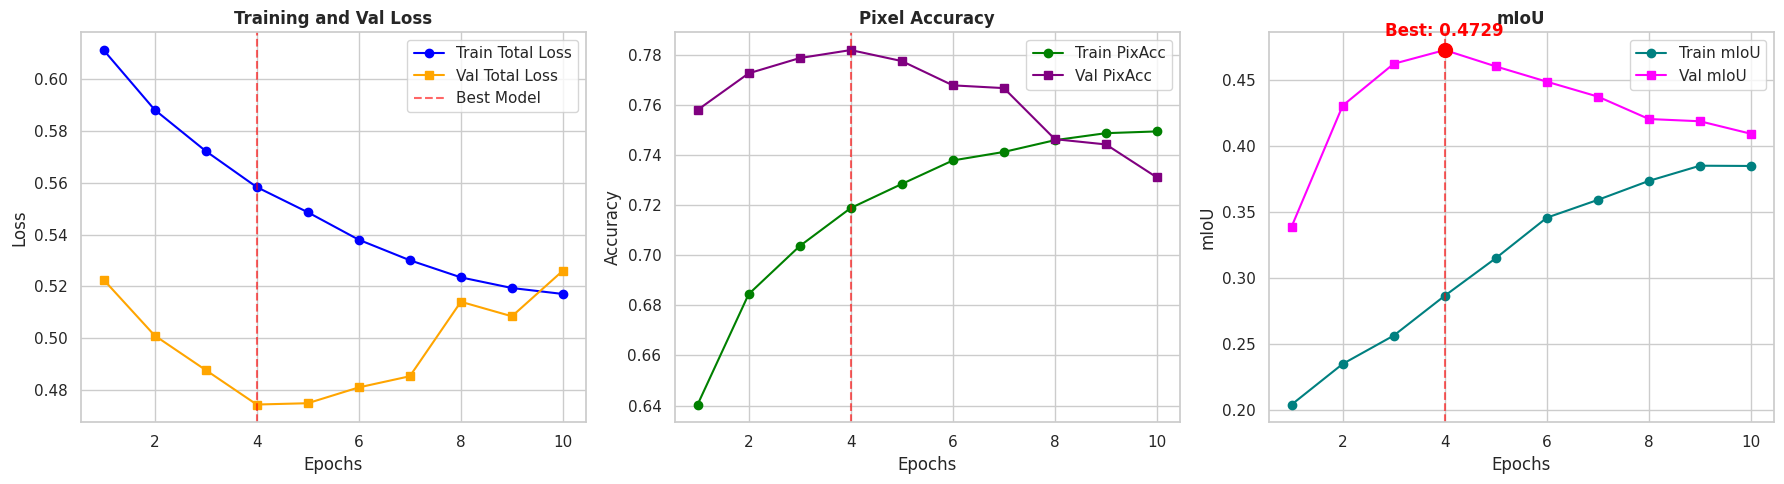

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
epochs = list(range(1, 11))

# Loss
train_loss = [0.6111, 0.5881, 0.5722, 0.5583, 0.5486, 0.5380, 0.5301, 0.5235, 0.5194, 0.5171]
val_loss = [0.5226, 0.5011, 0.4878, 0.4745, 0.4750, 0.4811, 0.4854, 0.5141, 0.5085, 0.5261]

# Pixel Accuracy
train_acc = [0.6404, 0.6845, 0.7037, 0.7189, 0.7285, 0.7379, 0.7413, 0.7460, 0.7488, 0.7495]
val_acc = [0.7581, 0.7727, 0.7788, 0.7820, 0.7776, 0.7679, 0.7668, 0.7464, 0.7443, 0.7311]

# mIoU
train_miou = [0.2041, 0.2349, 0.2564, 0.2866, 0.3151, 0.3458, 0.3593, 0.3737, 0.3852, 0.3850]
val_miou = [0.3391, 0.4308, 0.4625, 0.4729, 0.4605, 0.4489, 0.4376, 0.4206, 0.4189, 0.4094]

#  find the epoch at which the best model was trained
best_epoch = val_miou.index(max(val_miou)) + 1
best_miou = max(val_miou)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Graph: Loss
axes[0].plot(epochs, train_loss, label='Train Total Loss', color='blue', marker='o')
axes[0].plot(epochs, val_loss, label='Val Total Loss', color='orange', marker='s')
axes[0].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.6, label='Best Model')
axes[0].set_title('Training and Val Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# 2. Graph: Pixel Accuracy
axes[1].plot(epochs, train_acc, label='Train PixAcc', color='green', marker='o')
axes[1].plot(epochs, val_acc, label='Val PixAcc', color='purple', marker='s')
axes[1].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.6)
axes[1].set_title('Pixel Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# 3. Graph: mIoU
axes[2].plot(epochs, train_miou, label='Train mIoU', color='teal', marker='o')
axes[2].plot(epochs, val_miou, label='Val mIoU', color='magenta', marker='s')
axes[2].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.6)
# mark the best spot
axes[2].scatter(best_epoch, best_miou, color='red', s=100, zorder=5)
axes[2].annotate(f'Best: {best_miou:.4f}', (best_epoch, best_miou),
                 textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', color='red')
axes[2].set_title('mIoU', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('mIoU')
axes[2].legend()

plt.tight_layout()
plt.show()